# Relatório de Análise Preditiva: Árvores de Decisão (Diabetes)
**Instituição:** UFPA - Campus de Tucuruí  
**Disciplina:** Mineração de Dados  
**Professor:** Dr. Iago Medeiros  
**Grupo 07:** Pamella Roberta Ferreira da Silva e Fabricio Baia Vasconcelos  
**Data**: 30/04/2026  

---

## 1. Objetivo do Estudo
Este projeto consiste na implementação, análise e comparação de modelos de **Árvores de Decisão** para o diagnóstico preditivo de diabetes. O foco reside na avaliação técnica de como diferentes critérios matemáticos e restrições estruturais influenciam a capacidade do modelo de classificar pacientes entre saudáveis e diabéticos.

Foram executados dois ramos de análise:
1. **Experimento Profissional:** Focado no controle de **Profundidade Máxima** (limitação de camadas) para garantir a generalização do modelo e evitar o *overfitting* (decoreba de dados).
2. **Experimento Acadêmico:** Focado na variação da proporção de dados (**Split Treino/Teste**) e crescimento livre da árvore para observar o potencial máximo de exploração do algoritmo.

---

## 2. Metodologia de Avaliação
Para garantir um veredito técnico robusto, utilizamos cinco métricas fundamentais:
* **AUC (Área Sob a Curva):** Mede o poder global de separação entre as classes.
* **Acurácia:** Mede o percentual total de acertos.
* **Precisão:** Indica a confiabilidade das previsões positivas.
* **Recall (Sensibilidade):** Mede a capacidade de identificar doentes reais (métrica crítica para saúde).
* **F1-Score:** Média harmônica que indica o equilíbrio entre Precisão e Recall.

---

## 3. Implementação e Resultados
As células abaixo processam o conjunto de dados diabetes.csv, executam as baterias de testes e geram visualizações interativas para suporte à decisão clínica.

---

## 4. PREPARAÇÃO DO AMBIENTE E CARGA DE DADOS

Nesta etapa inicial, estabelecemos a infraestrutura necessária para a execução do projeto, garantindo que todas as dependências estejam configuradas e os dados devidamente processados para a modelagem.

### Descrição dos Procedimentos:

*   **Bloco 1 (Configuração do Kernel):** Ativa a extensão `autoreload` para atualizar automaticamente as modificações feitas no arquivo externo `.py` e configura o Matplotlib para renderizar gráficos diretamente nas células do Notebook (`inline`).
*   **Bloco 2 (Gestão de Dependências):** Realiza uma verificação automatizada (`try/except`) das bibliotecas essenciais (**Pandas, Scikit-Learn, Matplotlib e Ipywidgets**), iniciando a instalação caso alguma dependência não seja encontrada no ambiente.
*   **Bloco 3 (Importação de Módulos):** Importa as ferramentas de manipulação de dados, visualização e componentes interativos. Carrega também o motor customizado `modelagem_diabetes.py`, que contém as funções de suporte do projeto.
*   **Bloco 4 (Ingestão e Tratamento de Dados):** Realiza a leitura do *dataset* original e aplica o dicionário de tradução para converter os termos técnicos para o português, facilitando a interpretação clínica dos resultados.
*   **Bloco 5 (Segregação de Atributos):** Utiliza a lógica de engenharia de recursos para separar as variáveis explicativas (Features) da variável alvo (Target/Resultado), preparando o conjunto para o treinamento dos algoritmos.

---


In [18]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [19]:
try:
    import pandas, sklearn, matplotlib, ipywidgets
    print("✅ Ambiente configurado: Pandas, Sklearn, Matplotlib e Widgets prontos.")
except ImportError:
    print("⚠️ Dependências ausentes. Instalando bibliotecas necessárias...\n")
    %pip install pandas scikit-learn matplotlib ipywidgets
    print("\n✅ Instalação concluída.")

✅ Ambiente configurado: Pandas, Sklearn, Matplotlib e Widgets prontos.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from modelagem_diabetes import *

In [21]:
# Carga e Tradução
df_diabetes = pd.read_csv('diabetes.csv')
df_diabetes = df_diabetes.rename(columns=TRADUCAO_COLUNAS)
print("✅ Dados carregados e traduzidos!")
display(df_diabetes.head())

✅ Dados carregados e traduzidos!


,Gravidez,Glicose,Pressao,Pele,Insulina,IMC,Historico,Idade,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
# Separação de Recursos e Alvo
X, y = separar_recursos_e_alvo(df_diabetes)

---

## 5. EXECUÇÃO DOS EXPERIMENTOS

Nesta fase, o motor de modelagem processa as duas baterias de testes configuradas. O objetivo é submeter o algoritmo de Árvore de Decisão a diferentes cenários de estresse para identificar o comportamento das métricas de performance.

### Detalhamento das Etapas:

*   **Bloco 1 (Cenário Profissional):** Executa a modelagem com foco no controle de **hiperparâmetros de profundidade**. Mantém-se a divisão de dados fixa (75% treino / 25% teste) para isolar o impacto que o limite de camadas da árvore causa na capacidade de generalização do modelo.
*   **Bloco 2 (Cenário Acadêmico):** Executa a modelagem com foco na **variabilidade de dados**. Neste bloco, as árvores têm crescimento livre (sem limite de profundidade), variando-se as proporções de *split* entre treino e teste para observar a estabilidade do algoritmo diante de diferentes volumes de amostragem.
*   **Bloco 3 (Consolidação de Métricas):** Gera a visualização das tabelas de resultados brutos. Para garantir a clareza do relatório, os objetos complexos (como o modelo treinado e os vetores de predição) são ocultados nesta exibição, focando estritamente nos scores de **Acurácia, Precisão, Recall e F1-Score**.

---

In [23]:
# Experimento Profissional (Profundidade Limitada)
df_res_prof = executar_experimentos(X, y, EXP_PROFISSIONAL, eh_profissional=True)

In [24]:
# Experimento Acadêmico (Crescimento Livre / Split Variável)
df_res_acad = executar_experimentos(X, y, EXP_ACADEMICO, eh_profissional=False)

In [25]:
print("📊 Resultados brutos processados.")
display(df_res_prof.drop(columns=['modelo', 'y_real', 'y_previsto']))
display(df_res_acad.drop(columns=['modelo', 'y_real', 'y_previsto']))

📊 Resultados brutos processados.


,Acurácia,Precisão,Recall,F1-Score,X_teste
Configuracao,,,,,
Gini / Prof. 3,0.776042,0.760000,0.550725,0.638655,Gravidez Glicose Pressao Pele Insulin...
Gini / Prof. 5,0.765625,0.693548,0.623188,0.656489,Gravidez Glicose Pressao Pele Insulin...
Entropia / Prof. 3,0.776042,0.760000,0.550725,0.638655,Gravidez Glicose Pressao Pele Insulin...
Entropia / Prof. 5,0.718750,0.627119,0.536232,0.578125,Gravidez Glicose Pressao Pele Insulin...


,Acurácia,Precisão,Recall,F1-Score,X_teste
Configuracao,,,,,
Gini / 70-30,0.688312,0.589041,0.505882,0.544304,Gravidez Glicose Pressao Pele Insulin...
Gini / 80-20,0.694805,0.576923,0.545455,0.560748,Gravidez Glicose Pressao Pele Insulin...
Entropia / 70-30,0.735931,0.636364,0.658824,0.647399,Gravidez Glicose Pressao Pele Insulin...
Entropia / 80-20,0.727273,0.618182,0.618182,0.618182,Gravidez Glicose Pressao Pele Insulin...


---

## 6. COMPARAÇÃO GERAL (MÉTRICAS)

Esta seção transforma os dados numéricos em representações visuais, permitindo identificar padrões, tendências e discrepâncias entre os modelos de forma rápida e intuitiva.

### Detalhamento das Visualizações:

*   **Bloco 1 (Performance por Cenário):** Gera gráficos de barras individuais para os experimentos Profissional e Acadêmico. Estas visualizações destacam, através de **azul marinho**, o melhor desempenho alcançado em cada métrica dentro de seu respectivo grupo, facilitando a identificação dos modelos líderes de cada categoria.
*   **Bloco 2 (Duelo entre Estratégias):** Realiza o confronto direto entre as duas abordagens (Profundidade Controlada vs. Crescimento Livre) para cada uma das quatro métricas principais. O uso de cores contrastantes (**Teal e Laranja**) permite avaliar se o aumento da complexidade acadêmica de fato resulta em ganhos reais de performance frente à estabilidade do modelo profissional.

---

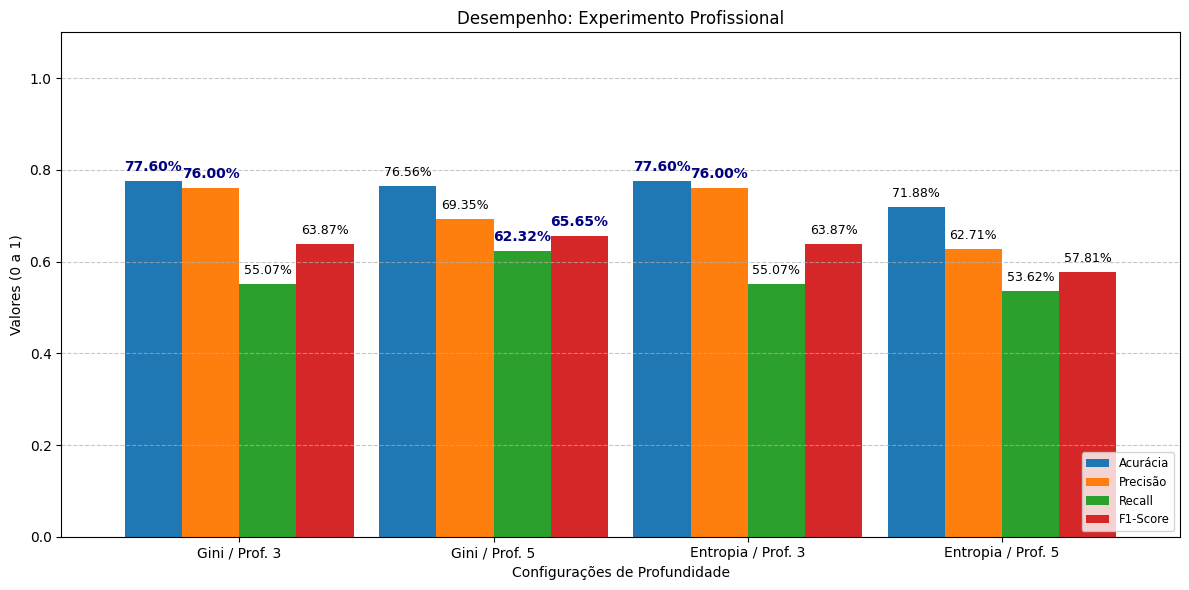

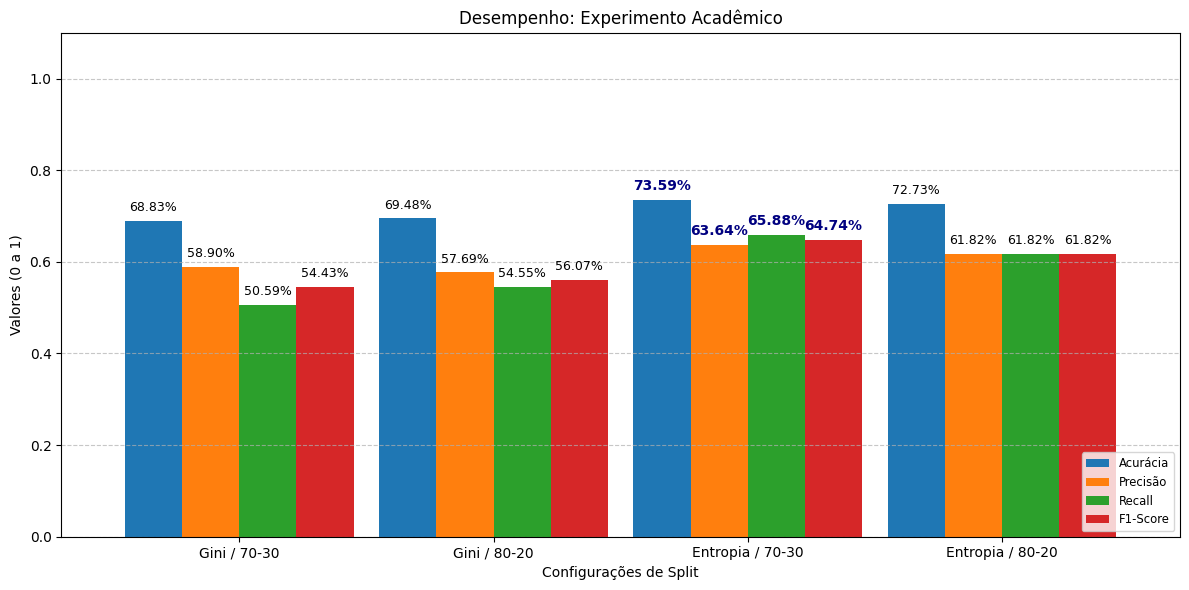

In [26]:
# Desempenho Individual por Experimento
plotar_comparativo_metricas(df_res_prof, "Desempenho: Experimento Profissional", "Configurações de Profundidade")
plotar_comparativo_metricas(df_res_acad, "Desempenho: Experimento Acadêmico", "Configurações de Split")

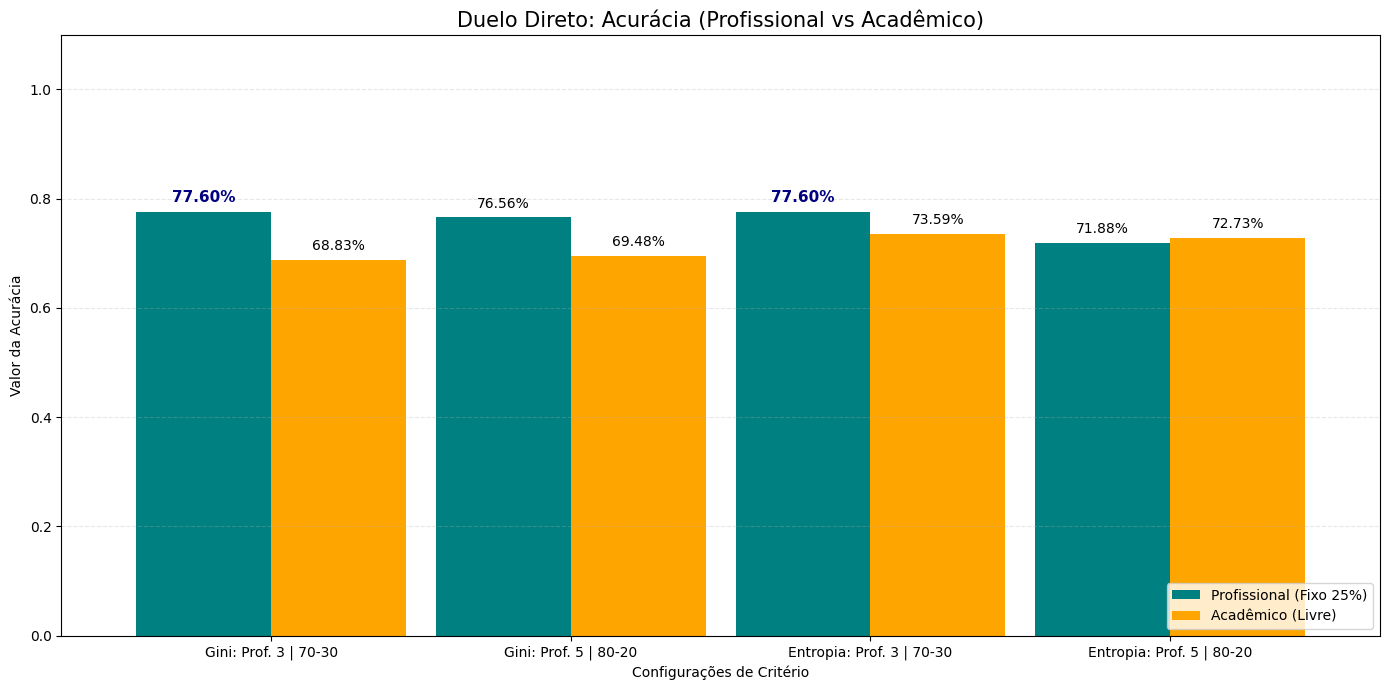

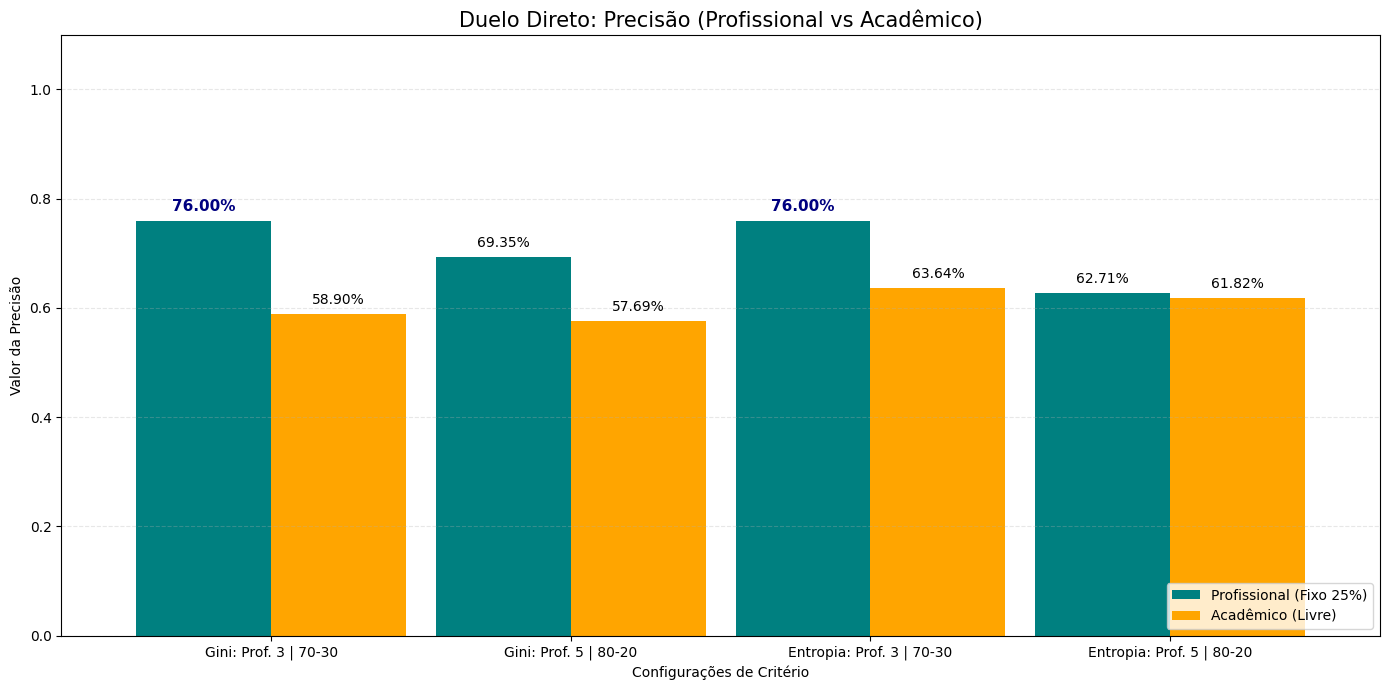

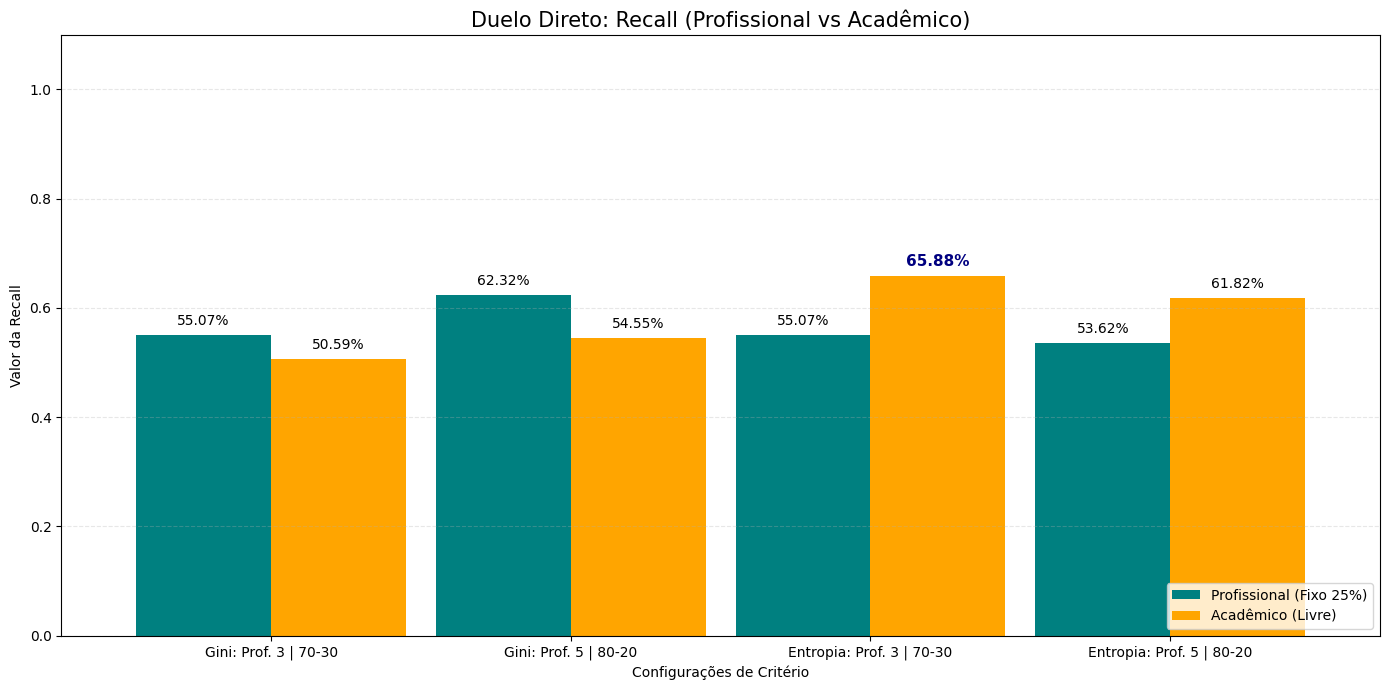

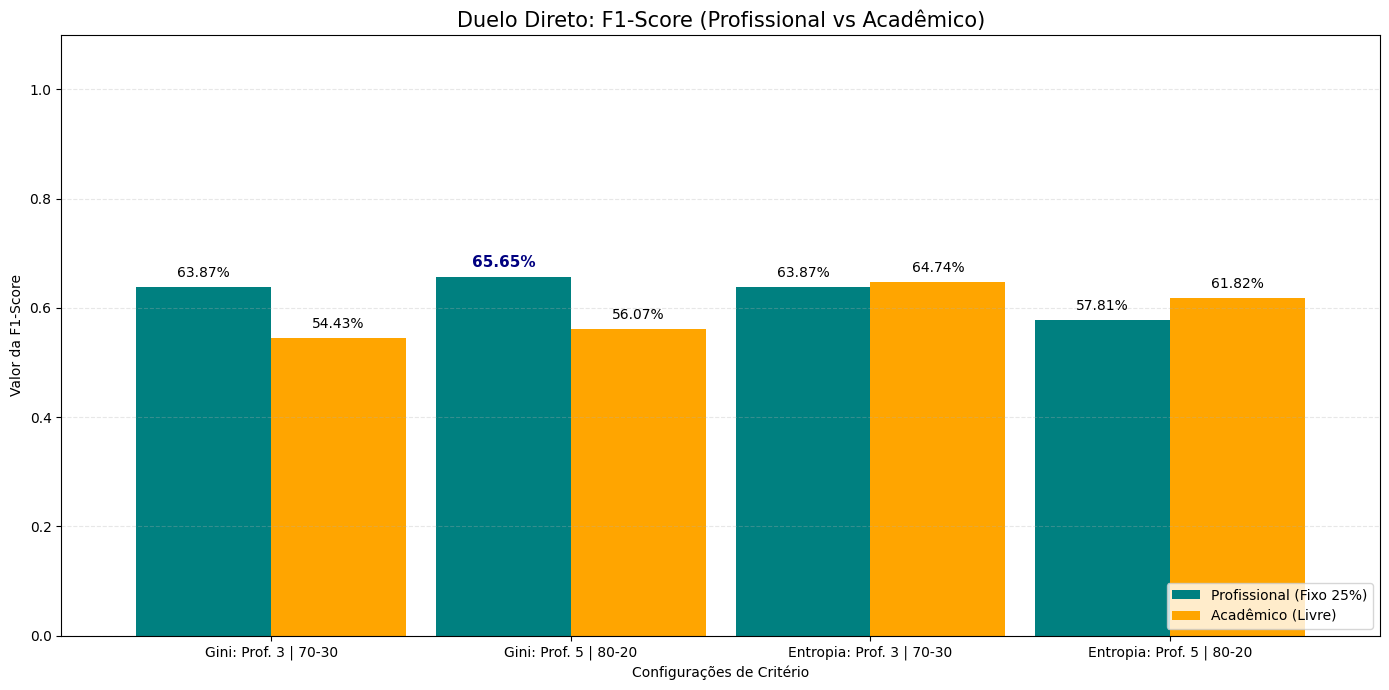

In [27]:
# Duelo Direto entre as Estratégias
plotar_comparativo_unificado(df_res_prof, df_res_acad, metrica='Acurácia')
plotar_comparativo_unificado(df_res_prof, df_res_acad, metrica='Precisão')
plotar_comparativo_unificado(df_res_prof, df_res_acad, metrica='Recall')
plotar_comparativo_unificado(df_res_prof, df_res_acad, metrica='F1-Score')

---

## 7. EXPLORAÇÃO INTERATIVA (POR MODELO)

Nesta seção, o relatório assume um caráter exploratório. Através de componentes interativos (*widgets*), é possível selecionar e confrontar qualquer par de modelos para uma análise granular e comparativa.

### Recursos Disponíveis:

*   **Bloco 1 (Impacto das Variáveis):** Permite identificar quais atributos do *dataset* (como Glicose ou IMC) foram mais determinantes para as decisões de cada modelo. A comparação lado a lado revela se a importância das variáveis permanece estável ou se altera conforme a complexidade da árvore aumenta.
*   **Bloco 2 (Diagnóstico de Erros):** Exibe as **Matrizes de Confusão** comparativas. Este recurso é vital para observar o equilíbrio entre Falsos Negativos e Falsos Positivos, permitindo avaliar a segurança clínica de um modelo específico frente a outro.
*   **Bloco 3 (Qualidade de Separação):** Apresenta as **Curvas ROC** individuais. Esta visualização foca na habilidade de cada modelo em distinguir as classes (Saudável vs. Diabético), exibindo o valor do **AUC** como indicador de performance global.

---

In [ ]:
print("\n🔍 EXPLORAÇÃO INTERATIVA: IMPORTÂNCIA DAS VARIÁVEIS")
criar_interface_comparativa(plotar_importancias_lado_a_lado, df_res_prof, df_res_acad, X.columns)


🔍 EXPLORAÇÃO INTERATIVA: IMPORTÂNCIA DAS VARIÁVEIS


Output()

In [29]:
print("\n🎭 EXPLORAÇÃO INTERATIVA: MATRIZES DE CONFUSÃO")
criar_interface_comparativa(plotar_matrizes_lado_a_lado, df_res_prof, df_res_acad)


🎭 EXPLORAÇÃO INTERATIVA: MATRIZES DE CONFUSÃO


Output()

In [30]:
print("\n📈 EXPLORAÇÃO INTERATIVA: CURVAS ROC LADO A LADO")
criar_interface_comparativa(plotar_roc_lado_a_lado, df_res_prof, df_res_acad)


📈 EXPLORAÇÃO INTERATIVA: CURVAS ROC LADO A LADO


Output()

---

## 8. O CLÍMAX: DUELO GLOBAL DE PODER PREDITIVO

Esta seção representa o ponto alto da análise técnica, onde os modelos de maior destaque de ambos os experimentos são colocados em um confronto direto e simultâneo.

### Detalhamento da Análise:

*   **Bloco 1 (Duelo de Curvas ROC Sobrepostas):** Utiliza uma interface de seleção quádrupla para sobrepor até quatro curvas ROC no mesmo plano cartesiano. Esta visualização é definitiva para identificar qual modelo possui a melhor "curva de aprendizado" e o maior **AUC (Área Sob a Curva)**. Ao confrontar as linhas, torna-se evidente qual estratégia (Profissional ou Acadêmica) entrega a maior robustez estatística na separação das classes.

---

In [31]:
print("\n⚔️ DUELO GLOBAL DE CURVAS ROC (4 MODELOS SOBREPOSTOS)")
criar_interface_quadrupla(df_res_prof, df_res_acad)


⚔️ DUELO GLOBAL DE CURVAS ROC (4 MODELOS SOBREPOSTOS)


Output()

---

## 9. ENCERRAMENTO E TOMADA DE DECISÃO

A etapa final deste relatório consolida todo o conhecimento gerado, transformando as métricas isoladas em uma recomendação estratégica baseada em evidências estatísticas e necessidades clínicas.

### Detalhamento da Tomada de Decisão:

*   **Bloco 1 (Hierarquia de Desempenho):** Apresenta o **Ranking Global** consolidado. A tabela é organizada por ordem de relevância clínica, priorizando o **AUC** e o **Recall**. Esta visão unificada permite identificar, de forma definitiva, quais modelos atingiram o equilíbrio superior entre poder de separação e segurança diagnóstica.
*   **Bloco 2 (Veredito Técnico Profissional):** Gera uma análise detalhada e justificada do modelo campeão do experimento técnico. O foco aqui é validar a viabilidade de implementação do modelo em ambiente real, destacando sua estabilidade e baixo risco de erro por complexidade excessiva.
*   **Bloco 3 (Conclusão do Estudo Acadêmico):** Apresenta o veredito sobre o experimento de crescimento livre. Esta conclusão foca no potencial de exploração do algoritmo e nos limites de aprendizado da Árvore de Decisão quando submetida a diferentes proporções de dados, fechando o ciclo de análise teórica do projeto.

---


In [32]:
# Ranking Consolidado
ranking_final = gerar_tabela_comparativa_completa(df_res_prof, df_res_acad)
print("\n🏆 RANKING GLOBAL DE DESEMPENHO (ORDEM DE RELEVÂNCIA CLÍNICA)")
display(ranking_final)


🏆 RANKING GLOBAL DE DESEMPENHO (ORDEM DE RELEVÂNCIA CLÍNICA)


,Estratégia,Configuração,AUC,Recall,F1-Score,Precisão,Acurácia
0,Profissional,Gini / Prof. 3,80.95%,55.07%,63.87%,76.00%,77.60%
2,Profissional,Entropia / Prof. 3,79.69%,55.07%,63.87%,76.00%,77.60%
1,Profissional,Gini / Prof. 5,79.60%,62.32%,65.65%,69.35%,76.56%
3,Profissional,Entropia / Prof. 5,77.28%,53.62%,57.81%,62.71%,71.88%
6,Acadêmica,Entropia / 70-30,71.98%,65.88%,64.74%,63.64%,73.59%
7,Acadêmica,Entropia / 80-20,70.30%,61.82%,61.82%,61.82%,72.73%
5,Acadêmica,Gini / 80-20,66.16%,54.55%,56.07%,57.69%,69.48%
4,Acadêmica,Gini / 70-30,65.02%,50.59%,54.43%,58.90%,68.83%


In [33]:
# Vereditos Finais Detalhados
gerar_conclusao_detalhada(df_res_prof, "Profissional")

📌 VEREDITO FINAL OTIMIZADO: EXPERIMENTO PROFISSIONAL
🏆 MODELO CAMPEÃO: Gini / Prof. 5
💡 ESTRATÉGIA: Controle de Profundidade
--------------------------------------------------------------------------------------------------------------
📊 AUC (Poder de Separação): 79.60%              -> Avalia a habilidade global de distinguir classes.
⚖️ F1-Score (Equilíbrio Técnico): 65.65%         -> Melhor indicador de estabilidade do modelo.
🎯 Acurácia (Assertividade Geral): 76.56%        -> Porcentagem total de acertos (Saudáveis + Diabéticos).
🩺 Recall (Segurança Clínica): 62.32%            -> Capacidade de encontrar doentes reais (Sensibilidade).
✅ Precisão (Confiabilidade): 69.35%             -> Confiança ao afirmar que um paciente tem diabetes.
--------------------------------------------------------------------------------------------------------------
📝 JUSTIFICATIVA TÉCNICA DETALHADA:
O modelo 'Gini / Prof. 5' foi eleito por sua excelente capacidade de GENERALIZAÇÃO. Com um AUC de 79.60%, e

In [34]:
# Vereditos Finais Detalhados
gerar_conclusao_detalhada(df_res_acad, "Acadêmico")

📌 VEREDITO FINAL OTIMIZADO: EXPERIMENTO ACADÊMICO
🏆 MODELO CAMPEÃO: Entropia / 70-30
💡 ESTRATÉGIA: Crescimento Livre
--------------------------------------------------------------------------------------------------------------
📊 AUC (Poder de Separação): 71.98%              -> Avalia a habilidade global de distinguir classes.
⚖️ F1-Score (Equilíbrio Técnico): 64.74%         -> Melhor indicador de estabilidade do modelo.
🎯 Acurácia (Assertividade Geral): 73.59%        -> Porcentagem total de acertos (Saudáveis + Diabéticos).
🩺 Recall (Segurança Clínica): 65.88%            -> Capacidade de encontrar doentes reais (Sensibilidade).
✅ Precisão (Confiabilidade): 63.64%             -> Confiança ao afirmar que um paciente tem diabetes.
--------------------------------------------------------------------------------------------------------------
📝 JUSTIFICATIVA TÉCNICA DETALHADA:
O modelo 'Entropia / 70-30' destacou-se no cenário acadêmico por sua CAPACIDADE EXPLICATIVA. Ao permitir o
crescime